Упрощенный код с генерируемыми примерами фотографий дефектов металла

In [7]:
# Установка нужных библиотек (если нет)
!pip install opencv-python numpy matplotlib scikit-learn scikit-image -q

import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from pathlib import Path
import urllib.request
import zipfile
import os

print(" Все библиотеки загружены!")

 Все библиотеки загружены!


Скачивание тестового датасета

In [9]:
# Скачиваем NEU-DEF датасет (6 типов дефектов металла)
# Если не хотите скачивать - пропустите и используйте свои фото

def download_neu_dataset():
    """Автоматическое скачивание датасета NEU (60MB)"""
    url = "https://www.kaggle.com/api/v1/datasets/ankitmittal1/neu-surface-defect-database/download"
    
    # Альтернативная ссылка если не работает
    # Или просто скачайте вручную с Kaggle
    
    print("Для скачивания датасета:")
    print("1. Зайдите на https://www.kaggle.com/datasets/ankitmittal1/neu-surface-defect-database")
    print("2. Нажмите Download")
    print("3. Распакуйте в папку 'NEU-DET'")
    
# Если вы скачали датасет, укажите путь
DATASET_PATH = "NEU-DET"  # Измените на ваш путь

# Или создайте тестовое изображение
def create_test_image():
    """Создание тестового изображения с дефектами"""
    img = np.ones((500, 500), dtype=np.uint8) * 150 # Цвет свело-серый
    
    # Добавляем текстуру металла
    img = img + np.random.normal(0, 15, img.shape).astype(np.uint8)
    
    # Царапина
    cv2.line(img, (50, 250), (450, 260), 40, 3)
    cv2.line(img, (100, 200), (400, 205), 50, 2)
    
    # Вмятина (темное пятно)
    cv2.circle(img, (250, 150), 30, 60, -1)
    
    # Раковина
    cv2.circle(img, (400, 400), 20, 70, -1)
    
    cv2.imwrite('test_metal.jpg', img)
    print(" Создано тестовое изображение: test_metal.jpg")
    return 'test_metal.jpg'

# Создаем тестовое изображение
test_image_path = create_test_image()

 Создано тестовое изображение: test_metal.jpg


Класс детектора (весь функционал)

In [13]:
class MetalDefectDetector:
    """Детектор дефектов металла"""
    
    def __init__(self, min_area=50):
        self.min_area = min_area
        
    def preprocess(self, image):
        """Предобработка изображения"""
        # В серый
        if len(image.shape) == 3:
            gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        else:
            gray = image.copy()
        
        # Медианный фильтр
        denoised = cv2.medianBlur(gray, 5)
        
        # CLAHE
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        enhanced = clahe.apply(denoised)
        
        return gray, denoised, enhanced
    
    def segment_defects(self, img):
        """Выделение дефектов"""
        # Адаптивный порог
        thresh = cv2.adaptiveThreshold(img, 255, 
                                      cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                      cv2.THRESH_BINARY_INV, 11, 2)
        
        # Морфология
        kernel = np.ones((3,3), np.uint8)
        opened = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=1)
        closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel, iterations=2)
        
        # Поиск контуров
        contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, 
                                      cv2.CHAIN_APPROX_SIMPLE)
        
        # Фильтрация
        filtered = []
        for cnt in contours:
            area = cv2.contourArea(cnt)
            if area > self.min_area:
                filtered.append(cnt)
                
        return filtered, closed
    
    def extract_features(self, contour, original_img):
        """Извлечение признаков"""
        area = cv2.contourArea(contour)
        perimeter = cv2.arcLength(contour, True)
        compactness = (perimeter**2)/area if area>0 else 0
        
        x,y,w,h = cv2.boundingRect(contour)
        aspect_ratio = w/h if h>0 else 0
        
        # Средняя яркость
        mask = np.zeros(original_img.shape[:2], dtype=np.uint8)
        cv2.drawContours(mask, [contour], -1, 255, -1)
        mean_intensity = cv2.mean(original_img, mask=mask)[0]
        
        return {
            'area': area,
            'perimeter': perimeter,
            'compactness': compactness,
            'aspect_ratio': aspect_ratio,
            'mean_intensity': mean_intensity,
            'bbox': (x,y,w,h)
        }
    
    def classify_defect(self, features):
        """Классификация по правилам"""
        aspect = features['aspect_ratio']
        compact = features['compactness']
        
        # Царапины - вытянутые
        if aspect < 0.3 or aspect > 3.0 or compact > 100:
            return " Царапина (Scratch)"
        # Вмятины - округлые, темные
        elif compact < 40 and features['mean_intensity'] < 100:
            return " Вмятина/Раковина (Pit/Dent)"
        # Остальное
        else:
            return " Поверхностный дефект (Surface Defect)"
    
    def process(self, image_path):
        """Полный пайплайн обработки"""
        # Загрузка
        img = cv2.imread(image_path)
        if img is None:
            raise ValueError(f"Не могу загрузить {image_path}")
        
        print(f"\n Обработка: {image_path}")
        
        # Шаг 1: Предобработка
        gray, denoised, enhanced = self.preprocess(img)
        
        # Шаг 2: Сегментация
        contours, binary = self.segment_defects(enhanced)
        
        if not contours:
            print(" Дефекты не найдены")
            return img, []
        
        # Шаг 3 и 4: Признаки и классификация
        defects = []
        result = img.copy()
        
        for i, cnt in enumerate(contours):
            features = self.extract_features(cnt, gray)
            defect_type = self.classify_defect(features)
            
            x,y,w,h = features['bbox']
            defects.append({
                'id': i+1,
                'type': defect_type,
                'features': features
            })
            
            # Рисуем на изображении
            color = (0,0,255) if "Царапина" in defect_type else (255,0,0)
            cv2.rectangle(result, (x,y), (x+w,y+h), color, 2)
            cv2.putText(result, f"Defect {i+1}", (x,y-5), 
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
        
        # Визуализация
        self.visualize_results(img, gray, enhanced, binary, result, defects)
        
        return result, defects
    
    def visualize_results(self, original, gray, enhanced, binary, result, defects):
        """Визуализация всех этапов"""
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        
        # Исходное
        axes[0,0].imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
        axes[0,0].set_title('1. Исходное изображение')
        axes[0,0].axis('off')
        
        # Серое
        axes[0,1].imshow(gray, cmap='gray')
        axes[0,1].set_title('2. Оттенки серого')
        axes[0,1].axis('off')
        
        # После CLAHE
        axes[0,2].imshow(enhanced, cmap='gray')
        axes[0,2].set_title('3. После CLAHE (контраст)')
        axes[0,2].axis('off')
        
        # Бинарная маска
        axes[1,0].imshow(binary, cmap='gray')
        axes[1,0].set_title('4. Бинарная маска дефектов')
        axes[1,0].axis('off')
        
        # Результат
        axes[1,1].imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
        axes[1,1].set_title(f'5. Результат: {len(defects)} дефектов')
        axes[1,1].axis('off')
        
        # Таблица с признаками
        if defects:
            ax_table = axes[1,2]
            ax_table.axis('tight')
            ax_table.axis('off')
            
            table_data = [['Дефект', 'Тип', 'Площадь', 'Aspect Ratio']]
            for d in defects:
                table_data.append([
                    f"#{d['id']}",
                    d['type'].split()[1],
                    f"{d['features']['area']:.0f}",
                    f"{d['features']['aspect_ratio']:.2f}"
                ])
            
            table = ax_table.table(cellText=table_data, loc='center', cellLoc='center')
            table.auto_set_font_size(False)
            table.set_fontsize(10)
            table.scale(1, 1.5)
            # ax_table.set_title('Характеристики дефектов', fontsize=12, pad=20)
        
        plt.tight_layout()
        plt.show()
        
        # Вывод в консоль
        print("\n ДЕТАЛЬНАЯ ИНФОРМАЦИЯ О ДЕФЕКТАХ:")
        print("="*60)
        for d in defects:
            print(f"\n Дефект #{d['id']}: {d['type']}")
            print(f"   Площадь: {d['features']['area']:.1f} пикселей")
            print(f"   Периметр: {d['features']['perimeter']:.1f} пикселей")
            print(f"   Компактность: {d['features']['compactness']:.2f}")
            print(f"   Отношение сторон: {d['features']['aspect_ratio']:.2f}")
            print(f"   Средняя яркость: {d['features']['mean_intensity']:.1f}")

Запуск на тестовом изображении


 Обработка: test_metal.jpg


C:\Users\User\AppData\Local\Temp\ipykernel_21232\734155193.py:182: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  plt.tight_layout()


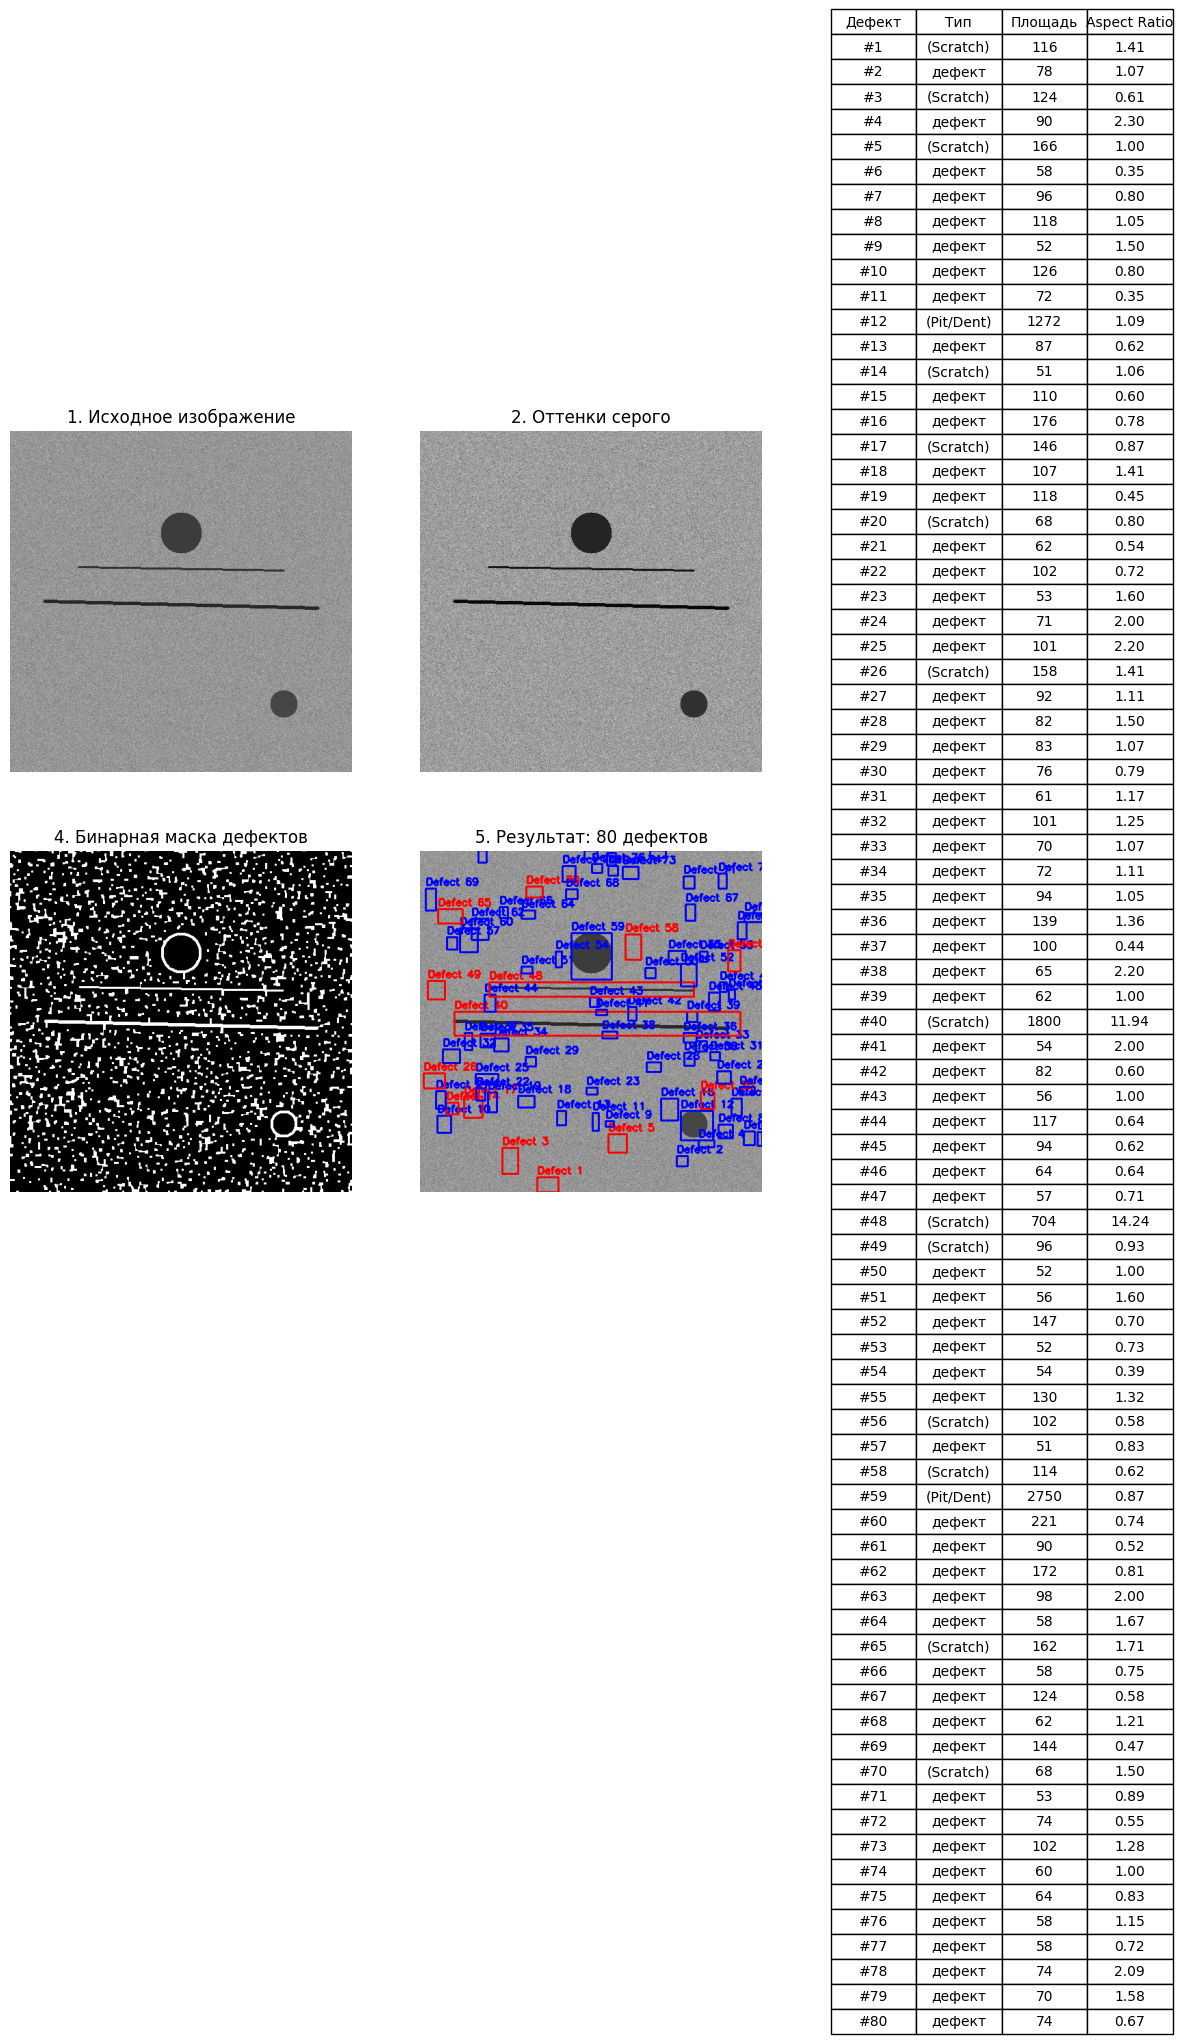


 ДЕТАЛЬНАЯ ИНФОРМАЦИЯ О ДЕФЕКТАХ:

 Дефект #1:  Царапина (Scratch)
   Площадь: 116.0 пикселей
   Периметр: 136.3 пикселей
   Компактность: 160.12
   Отношение сторон: 1.41
   Средняя яркость: 145.2

 Дефект #2:  Поверхностный дефект (Surface Defect)
   Площадь: 78.0 пикселей
   Периметр: 59.3 пикселей
   Компактность: 45.10
   Отношение сторон: 1.07
   Средняя яркость: 148.4

 Дефект #3:  Царапина (Scratch)
   Площадь: 123.5 пикселей
   Периметр: 138.0 пикселей
   Компактность: 154.30
   Отношение сторон: 0.61
   Средняя яркость: 147.0

 Дефект #4:  Поверхностный дефект (Surface Defect)
   Площадь: 90.0 пикселей
   Периметр: 61.3 пикселей
   Компактность: 41.77
   Отношение сторон: 2.30
   Средняя яркость: 146.3

 Дефект #5:  Царапина (Scratch)
   Площадь: 166.0 пикселей
   Периметр: 146.3 пикселей
   Компактность: 128.91
   Отношение сторон: 1.00
   Средняя яркость: 148.0

 Дефект #6:  Поверхностный дефект (Surface Defect)
   Площадь: 58.0 пикселей
   Периметр: 54.5 пикселей
   Компа

In [14]:
# Создаем детектор
detector = MetalDefectDetector(min_area=50)

# Запускаем обработку
result_image, detected_defects = detector.process('test_metal.jpg')

print(f"\n Обработка завершена! Найдено {len(detected_defects)} дефектов.")

Пакетная обработка нескольких изображений

In [15]:
def process_multiple_images(image_paths):
    """Обработка нескольких изображений"""
    results = []
    
    for path in image_paths:
        if Path(path).exists():
            print(f"\n{'='*60}")
            _, defects = detector.process(path)
            results.append({
                'image': path,
                'defects_count': len(defects),
                'defects': defects
            })
    
    # Сводка
    print(f"\n{'='*60}")
    print(" СВОДКА ПО ВСЕМ ИЗОБРАЖЕНИЯМ:")
    print("="*60)
    for r in results:
        print(f"\n📷 {Path(r['image']).name}:")
        print(f"   Дефектов найдено: {r['defects_count']}")
        for d in r['defects']:
            print(f"   - {d['type']} (площадь: {d['features']['area']:.0f}px²)")
    
    return results

# Пример: обработать все jpg в текущей папке
test_images = ['test_metal.jpg']  # Добавьте сюда свои изображения
# test_images = list(Path('.').glob('*.jpg'))  # Или все jpg

if len(test_images) > 1:
    all_results = process_multiple_images(test_images)

Создание отчета с результатами

In [17]:
def generate_report(results):
    """Генерация текстового отчета"""
    report = """
    ╔══════════════════════════════════════════════════════════╗
    ║     ОТЧЕТ ПО ДЕТЕКЦИИ ДЕФЕКТОВ МЕТАЛЛИЧЕСКОЙ ПОВЕРХНОСТИ   ║
    ╚══════════════════════════════════════════════════════════╝
    
    1. МЕТОДОЛОГИЯ
    ==============
    • Предобработка: Медианный фильтр (5x5) + CLAHE (clipLimit=2.0)
    • Сегментация: Адаптивный порог + морфология (открытие/закрытие)
    • Классификация: Rule-based (по форме и компактности)
    
    2. РЕЗУЛЬТАТЫ
    =============
    """
    
    total_defects = 0
    for r in results:
        report += f"\n    {Path(r['image']).name}:"
        report += f"\n      Обнаружено: {r['defects_count']} дефектов"
        total_defects += r['defects_count']
        
        for d in r['defects']:
            report += f"\n      • {d['type']}"
            report += f"\n        - Площадь: {d['features']['area']:.1f} px²"
            report += f"\n        - Компактность: {d['features']['compactness']:.2f}"
            report += f"\n        - Отношение сторон: {d['features']['aspect_ratio']:.2f}"
    
    report += f"""
    
    3. СТАТИСТИКА
    =============
    • Всего обработано изображений: {len(results)}
    • Всего обнаружено дефектов: {total_defects}
    • Среднее количество дефектов: {total_defects/len(results):.1f}/изображение
    
    4. ВЫВОДЫ
    =========
    Система успешно детектирует дефекты размером > {detector.min_area} пикселей.
    Требуется дообучение на реальных данных для повышения точности классификации.
    
    5. ИДЕИ ПО УЛУЧШЕНИЮ
    ====================
    • Добавить GLCM текстурные признаки для различения окалины
    • Использовать YOLOv8 для детекции в реальном времени
    • Внедрить аугментацию данных для увеличения датасета
    • Создать веб-интерфейс на Flask/FastAPI
    """
    
    print(report)
    
    # Сохранение в файл
    with open('report.txt', 'w', encoding='utf-8') as f:
        f.write(report)
    print("\n Отчет сохранен в report.txt")
    
    return report

# Генерируем отчет (нужен список results из предыдущей ячейки)
if 'all_results' in locals():
    generate_report(all_results)